In [1]:
import pandas as pd

df = pd.read_csv("../data/processed/music_memory_processed.csv")

In [2]:
X = df.drop(
    columns=[
        "digit_span",
        "spatial_span",
        "melody_span"
    ]
)

y = df[
    [
        "digit_span",
        "spatial_span",
        "melody_span"
    ]
]

In [3]:
print(X.shape)

print(y.shape)

(1425, 13)
(1425, 3)


In [4]:
correlation = df.corr(numeric_only=True)

In [5]:
memory_corr = correlation[
    [
        "digit_span",
        "spatial_span",
        "melody_span"
    ]
]

memory_corr.sort_values(
    by="melody_span",
    ascending=False
)

,digit_span,spatial_span,melody_span
melody_span,0.337661,0.204693,1.000000
gold_msi_musical_training,0.091760,0.154946,0.500391
gold_msi_general_sophistication,0.109385,0.115327,0.482651
digit_span,1.000000,0.301799,0.337661
gold_msi_active_engagement,0.078594,0.052639,0.333351
bfi_open_mindedness,0.019640,0.014787,0.240020
spatial_span,0.301799,1.000000,0.204693
ses_nuclear_family,0.146684,0.079101,0.144337
bfi_agreeableness,0.016878,-0.017578,0.085729
years_of_education,0.009608,0.038639,0.078305


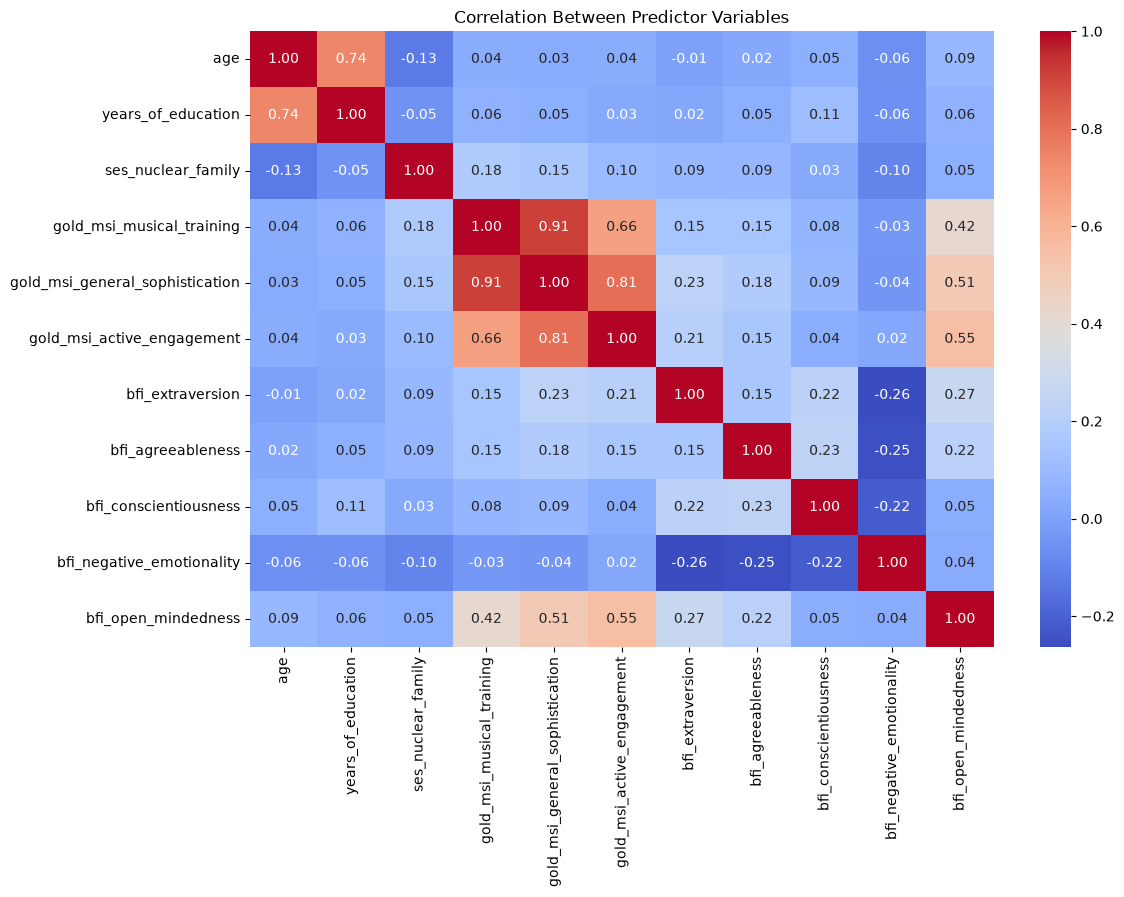

In [6]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12,8))

sns.heatmap(
    X.corr(numeric_only=True),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Between Predictor Variables")

plt.show()

## Feature Correlation Analysis

### Melody Span

- Gold-MSI Musical Training demonstrated the strongest positive correlation with Melody Span (r = 0.500).
- Gold-MSI General Sophistication (r = 0.483) and Gold-MSI Active Engagement (r = 0.333) also showed positive associations with Melody Span.
- These findings suggest that musical experience is more strongly related to auditory working memory than other measured variables.

### Digit Span

- Digit Span showed its strongest associations with Melody Span (r = 0.338) and Spatial Span (r = 0.302).
- Musical variables exhibited only weak correlations with Digit Span, suggesting a limited relationship with verbal working memory.

### Spatial Span

- Spatial Span was most strongly associated with Digit Span (r = 0.302).
- Musical variables displayed relatively weak positive correlations with Spatial Span.

### Summary

- Melody Span appears to be the memory measure most strongly associated with musical experience.
- Digit Span and Spatial Span demonstrate stronger relationships with other memory measures than with musical training variables.
- Feature selection should consider both correlation strength and multicollinearity before model development.

In [8]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

In [9]:
X_numeric = X.select_dtypes(include="number")

In [10]:
vif = pd.DataFrame({
    "Feature": X_numeric.columns,
    "VIF": [
        variance_inflation_factor(X_numeric.values, i)
        for i in range(X_numeric.shape[1])
    ]
})

vif = vif.sort_values(by="VIF", ascending=False)

vif

,Feature,VIF
1,years_of_education,117.099983
4,gold_msi_general_sophistication,116.901496
0,age,105.587704
10,bfi_open_mindedness,65.435897
7,bfi_agreeableness,49.004419
5,gold_msi_active_engagement,47.784240
6,bfi_extraversion,30.065861
3,gold_msi_musical_training,28.750049
8,bfi_conscientiousness,25.992414
9,bfi_negative_emotionality,13.158271


In [13]:
from statsmodels.tools.tools import add_constant
from statsmodels.stats.outliers_influence import variance_inflation_factor

X_vif = add_constant(X_numeric)

vif = pd.DataFrame({
    "Feature": X_vif.columns,
    "VIF": [
        variance_inflation_factor(X_vif.values, i)
        for i in range(X_vif.shape[1])
    ]
})

vif = vif.sort_values("VIF", ascending=False)

vif

,Feature,VIF
0,const,203.072212
5,gold_msi_general_sophistication,11.101511
4,gold_msi_musical_training,6.889211
6,gold_msi_active_engagement,3.398918
1,age,2.286901
2,years_of_education,2.255706
11,bfi_open_mindedness,1.585033
7,bfi_extraversion,1.241517
10,bfi_negative_emotionality,1.197761
8,bfi_agreeableness,1.177248


## Variance Inflation Factor (VIF) Analysis

Variance Inflation Factor (VIF) was calculated to assess multicollinearity among the predictor variables.

### Key Findings

- Gold-MSI General Sophistication exhibited the highest VIF (11.10), indicating substantial overlap with other musical experience variables.
- Gold-MSI Musical Training showed moderate multicollinearity (VIF = 6.89), likely due to its strong association with General Sophistication.
- Gold-MSI Active Engagement demonstrated acceptable multicollinearity (VIF = 3.40).
- Age and Years of Education showed low VIF values despite their positive correlation, suggesting that both variables provide complementary information.
- All personality traits and socioeconomic status displayed minimal multicollinearity.

### Interpretation

The VIF analysis suggests that the musical experience variables contain overlapping information. However, no predictors were removed at this stage because the primary objective of this study is to understand the relationship between musical training and different domains of working memory. Alternative regression models with and without highly collinear variables will be compared during the modeling phase to evaluate their impact on predictive performance and model interpretability.